# AM10 - Module: Intermediate

## Lecture 11


### Learning objectives:
Random numbers, Monte Carlo integration, one-dimensional random walk

_____________________________________________________________________

In [1]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

### 1. Random numbers

How can a deterministic machine like a computer produce "random" numbers? They are not really random, they are generated by an algorithm, but they satisfy all the conditions of true random numbers within some approximation.  They are called "pseudo-random" numbers.

The most common algorithm is the modulo algorithm:

r[n+1] = mod[(A * r[n] + B),M]/M, A,B,M: large integers, and need a seed to get started.

This produces random numbers in the range [0,1).  We can then shift and scale them to cover unifromly any interval. 

These look good for a while, but eventually they start repeating, as you can easily show if you choose the values of A, B, M to be small (for larger values this problem is delayed, but it NOT avoided).

Moreover, if you go to higher dimensions, like generating pairs of numbers (x,y) to cover a region of the plane uniformly, you discover deeper problems. 

#### It takes hard work to create a good RNG!!!

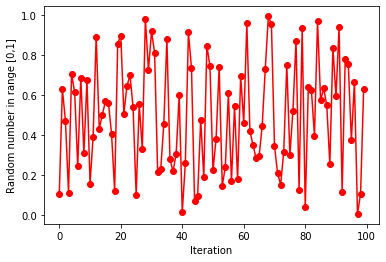

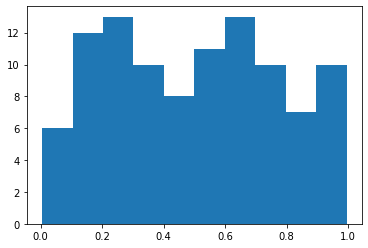

In [3]:
# Example 1: build our own RNG based on modulo

N=100

A=1000
B=400
M=197
seed=21

rnum=np.zeros(N)
rnum[0]=seed

for n in range(N-1):
    rnum[n+1]=np.mod((A*rnum[n]+B),M)
    
rnum=rnum/M

plt.plot(rnum,'ro-')
plt.xlabel('Iteration')
plt.ylabel('Random number in range [0,1]')
plt.show()

plt.hist(rnum)
plt.show()

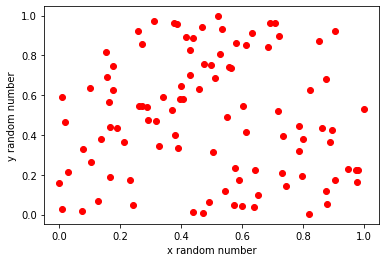

In [6]:
# Example 2: use numbers from our RNG to cover the plane as (x,y) coordinates

N=100

A=10000
B=400
M=1957
xseed=21
yseed=59

xnum=np.zeros(N)
xnum[0]=xseed
ynum=np.zeros(N)
ynum[0]=yseed

for n in range(N-1):
    xnum[n+1]=np.mod((A*xnum[n]+B),M)
    ynum[n+1]=np.mod((A*ynum[n]+B),M)
    
xnum=xnum/M
ynum=ynum/M

plt.plot(xnum,ynum,'ro')
plt.xlabel('x random number')
plt.ylabel('y random number')
plt.show()


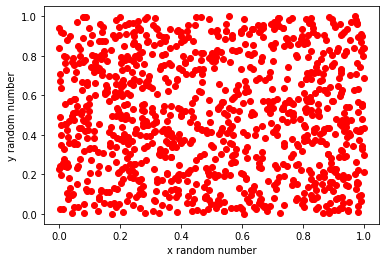

In [9]:
# Repeat above with intrinsic random number generator
N=1000
xl=np.random.rand(N)
yl=np.random.rand(N)

plt.plot(xl,yl,'ro')
plt.xlabel('x random number')
plt.ylabel('y random number')
plt.show()


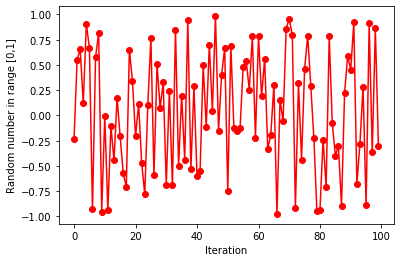

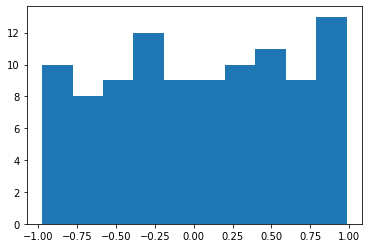

In [12]:
# Example 3: use the uniform distribution to produce another desired disribution: 
#
#
# uniform distributin in the interval [-1,+1]
#

N=100
rnum=2*np.random.rand(N)-1

plt.plot(rnum,'ro-')
plt.xlabel('Iteration')
plt.ylabel('Random number in range [0,1]')
plt.show()

plt.hist(rnum)
plt.show()

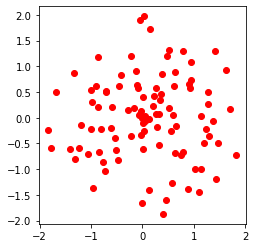

In [14]:
# Example 4: uniform RADIAL distribution within circle of radius R
#           distance from origin is random (from 0 to R)
#           angle phi relative to x-axis is random (from 0 to 2*pi)

R=2.0
N=100
rv=R*np.random.rand(N)
ph=2*np.pi*np.random.rand(N)
xv=rv*np.cos(ph)
yv=rv*np.sin(ph)

plt.plot(xv,yv,'ro')
plt.gca().set_aspect('equal',adjustable='box')
plt.show()

In [15]:
def plt_true(yval,M):
    xtr=np.zeros(2)
    ytr=np.zeros(2)
    xtr[0]=1
    xtr[1]=M
    ytr[0]=yval
    ytr[1]=yval
    plt.plot(xtr,ytr,'r--')
    return

### Calculate PI!

<img src="mc_pi.png" alt="Drawing" style="width: 300px;"/>

Area of circle (radius $R= 1$):

$$ A_C = \pi R^2 = \pi$$

Area of square (side $S=2$):

$$ A_S = S^2 = 4$$

Ratio of areas:

$$\frac{A_C}{A_S} = \frac{\pi}{4} = 0.7853975$$



10 3.6
100 3.28
1000 3.104
10000 3.1324
100000 3.13748
1000000 3.145428


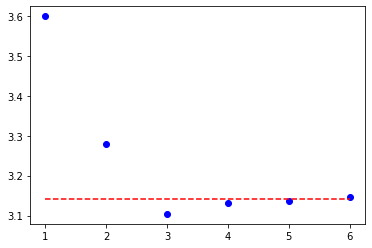

In [23]:
# Example 5: calculate pi!

Mmax=6
Nsav=np.zeros(Mmax)
pisav=np.zeros(Mmax)

for m in range(Mmax):

    pisum=0.0
    N=10**(m+1)
    for n in range(N):
        x=np.random.rand()
        y=np.random.rand()
        if (x**2+y**2<1.0):
            pisum=pisum+1.0
    
    Nsav[m]=m+1
    pisav[m]=4*pisum/N
    print(N,4*pisum/N)


plt.plot(Nsav,pisav,'bo')
plt_true(np.pi,Mmax)
plt.show()

### Calculate intgral of x^3 from 0 t0 1

<img src="mcint_x2.png" alt="Drawing" style="width: 300px;"/>

Area under the curve of $x^3$:

$$ A_C = \int_0^1 x^3 dx = \left [ \frac{1}{4} x^4 \right]^1_0=0.25$$

Area of square (side $S=1$):

$$ A_S = S^2 = 1$$

Ratio of areas:

$$\frac{A_C}{A_S} = 0.25$$



10 0.3
100 0.23
1000 0.235
10000 0.2529
100000 0.24918
1000000 0.250192


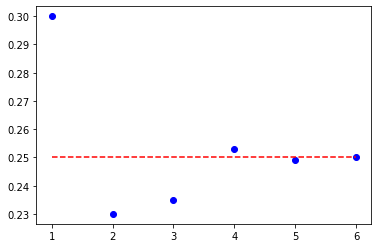

In [26]:
# Example 6: calculate integral of x^3 from x=0 to 1.

def fofx(x):
    return x**3

Mmax=6
Nsav=np.zeros(Mmax)
x3sav=np.zeros(Mmax)

for m in range(Mmax):

    x3sum=0.0
    N=10**(m+1)
    for n in range(N):
        x=np.random.rand()
        y=np.random.rand()
        if (y<fofx(x)):
            x3sum=x3sum+1.0
    
    Nsav[m]=m+1
    x3sav[m]=x3sum/N
    print(N,x3sum/N)


plt.plot(Nsav,x3sav,'bo')
plt_true(0.25,Mmax)
plt.show()
